In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df = pd.read_csv('/Users/anshtomar/PROJECTS/Credit-Risk-Scorecard/data/cs-training.csv', index_col=0)
print(df.shape)
print("Loaded successfully!")


(150000, 11)
Loaded successfully!


In [13]:
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [15]:
# Step 3 - Target Variable Analysis
target = 'SeriousDlqin2yrs'

print(df[target].value_counts())
print()
print(df[target].value_counts(normalize=True) * 100)


SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

SeriousDlqin2yrs
0    93.316
1     6.684
Name: proportion, dtype: float64


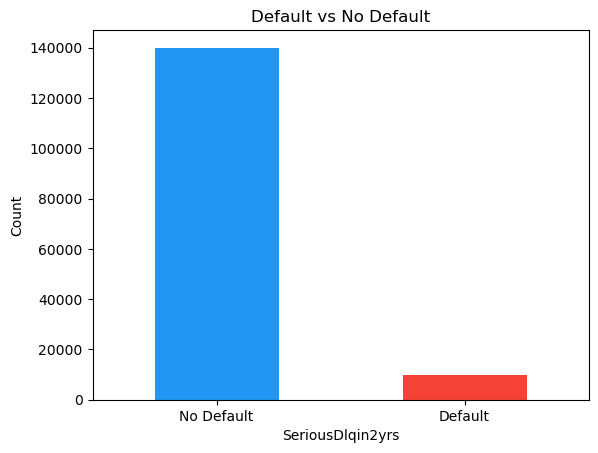

In [16]:
# Step 3 - Plot
df[target].value_counts().plot(
    kind='bar',
    color=['#2196F3', '#F44336'],
    title='Default vs No Default'
)
plt.xticks([0,1], ['No Default', 'Default'], rotation=0)
plt.ylabel('Count')
plt.show()


## Key Observation
Dataset is highly imbalanced — 93.3% No Default vs 6.7% Default.
Accuracy is a misleading metric here.
Will use AUC-ROC, KS and Gini instead.


In [17]:
# Step 4 - Missing Value Analysis
print(df.isnull().sum())
print()
print("Missing %")
print(df.isnull().sum() / len(df) * 100)


SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

Missing %
SeriousDlqin2yrs                         0.000000
RevolvingUtilizationOfUnsecuredLines     0.000000
age                                      0.000000
NumberOfTime30-59DaysPastDueNotWorse     0.000000
DebtRatio                                0.000000
MonthlyIncome                           19.820667
NumberOfOpenCreditLinesAndLoans          0.000000
NumberOfTimes90DaysLate                  0.000000
NumberRealEstateLoansOrLines             0.000000
NumberOfTime60-89Day

## 📝 

- Only 2 features have missing values:
  - MonthlyIncome → 19.8% missing
  - NumberOfDependents → 2.6% missing

- Fix Strategy:
  - MonthlyIncome → median grouped by age bracket
  - NumberOfDependents → fill with 0

- Why median not mean?
  - Income has outliers, median is more robust

- What to say in interview:
  "MonthlyIncome had 19.8% missing values. I imputed 
  with median grouped by age bracket because income 
  varies significantly by age."


In [18]:
# Step 5 - Descriptive Statistics
df.describe()


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


## 📝 Step 5 - Key Observations

- Age min = 0 → data error, will remove age < 18
- RevolvingUtilization max = 50,708 → extreme outlier
- DebtRatio max = 329,664 → extreme outlier
- These outliers will be handled naturally 
  by WoE binning in Phase 2


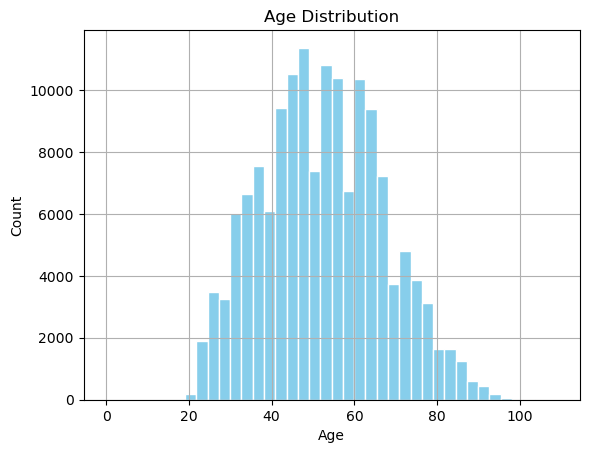

In [21]:
# Step 6 - Distribution of Age
df['age'].hist(bins=40, color='skyblue', edgecolor='white')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()


## 📝 Age Distribution
- Most borrowers: 40-65 years
- Right skewed distribution
- Very few young borrowers (makes sense — 
  younger people have less credit history)


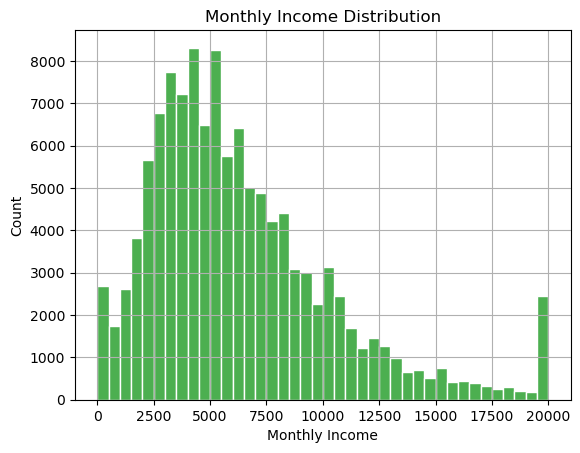

In [22]:
# Monthly Income Distribution
df['MonthlyIncome'].dropna().clip(upper=20000).hist(
    bins=40, color='#4CAF50', edgecolor='white')
plt.title('Monthly Income Distribution')
plt.xlabel('Monthly Income')
plt.ylabel('Count')
plt.show()


## 📝 Monthly Income Distribution
- Most borrowers earn $2,500 - $7,500/month
- Right skewed — few very high earners
- This is why we use MEDIAN not MEAN 
  for imputation (outliers pull mean up)


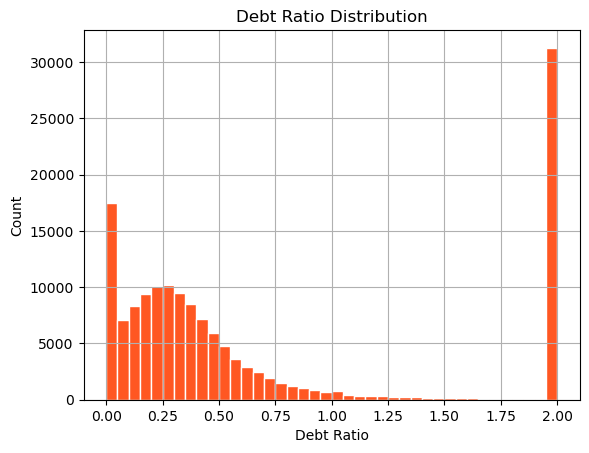

In [23]:
# Step 6 - Debt Ratio Distribution
df['DebtRatio'].clip(upper=2).hist(
    bins=40, color='#FF5722', edgecolor='white')
plt.title('Debt Ratio Distribution')
plt.xlabel('Debt Ratio')
plt.ylabel('Count')
plt.show()


## 📝 Debt Ratio Distribution
- Most borrowers: debt ratio < 0.5 (healthy)
- Extreme outliers exist (max = 329,664!)
- Values above 1.0 mean debt > income = risky
- Outliers handled by WoE binning in Phase 2


/var/folders/yp/dn45sb3172n7hnjmssht9y980000gn/T/ipykernel_10456/876869538.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  default_by_age = df.groupby('age_group')['SeriousDlqin2yrs'].mean() * 100


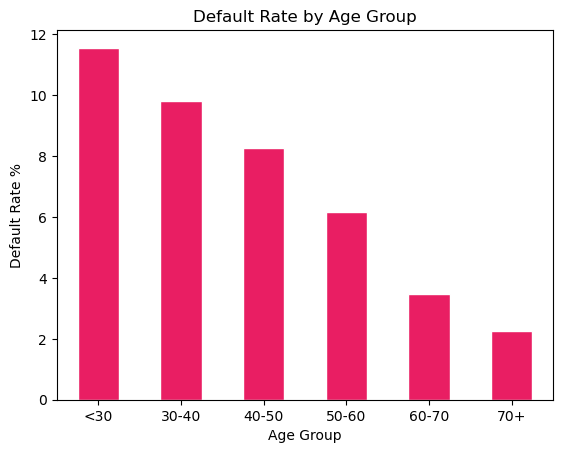

In [24]:
# Step 7 - Default Rate by Age Group
df['age_group'] = pd.cut(df['age'], 
                          bins=[0,30,40,50,60,70,120],
                          labels=['<30','30-40','40-50',
                                  '50-60','60-70','70+'])

default_by_age = df.groupby('age_group')['SeriousDlqin2yrs'].mean() * 100

default_by_age.plot(kind='bar', color='#E91E63', edgecolor='white')
plt.title('Default Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Default Rate %')
plt.xticks(rotation=0)
plt.show()


## 📝 Default Rate by Age — Key Insight!

- Under 30: ~11% default rate (HIGHEST)
- 70+: ~2.5% default rate (LOWEST)
- Younger borrowers are 4x more likely to default
- This makes Age a strong predictor in our model
- Business insight: Amex should be more cautious 
  with credit limits for borrowers under 30


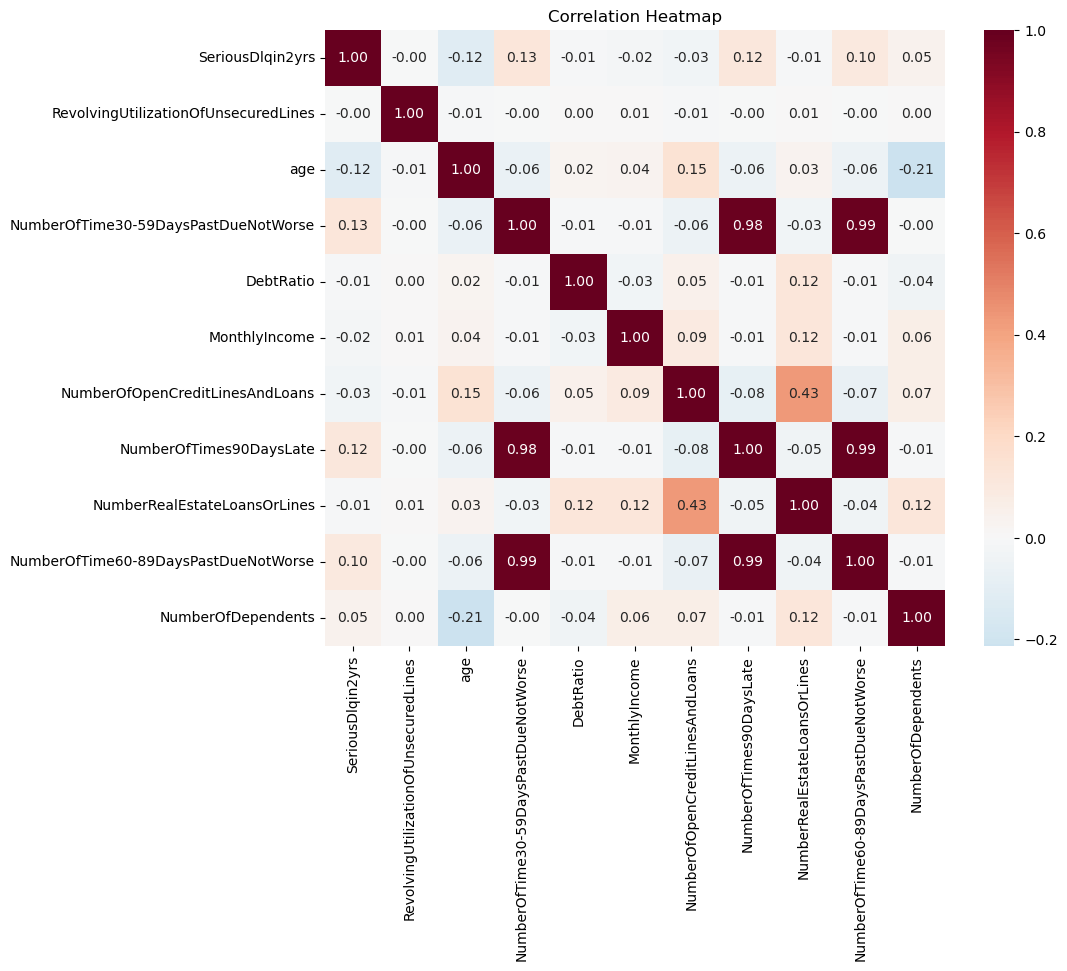

In [26]:
# Step 8 - Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), 
            annot=True, 
            fmt='.2f', 
            cmap='RdBu_r',
            center=0)
plt.title('Correlation Heatmap')
plt.show()


## 📝 Correlation Heatmap Insights

- 3 late payment features are 98-99% correlated
  - 30-59 days late
  - 60-89 days late  
  - 90+ days late
- WoE/IV in Phase 2 will naturally handle this
  by selecting only the most informative feature
- Age has negative correlation with default
  (older = less likely to default) ✅


In [28]:
# Step 9 - Outlier Analysis
df_numeric = df.select_dtypes(include='number')

Q1 = df_numeric.quantile(0.25)
Q3 = df_numeric.quantile(0.75)
IQR = Q3 - Q1

outliers = ((df_numeric < (Q1 - 1.5*IQR)) | 
            (df_numeric > (Q3 + 1.5*IQR))).sum()

print("Number of Outliers per feature:")
print(outliers)


Number of Outliers per feature:
SeriousDlqin2yrs                        10026
RevolvingUtilizationOfUnsecuredLines      763
age                                        46
NumberOfTime30-59DaysPastDueNotWorse    23982
DebtRatio                               31311
MonthlyIncome                            4879
NumberOfOpenCreditLinesAndLoans          3980
NumberOfTimes90DaysLate                  8338
NumberRealEstateLoansOrLines              793
NumberOfTime60-89DaysPastDueNotWorse     7604
NumberOfDependents                      13336
dtype: int64


## 📝 Outlier Analysis

- MonthlyIncome has 31,311 outliers
- DebtRatio has 23,982 outliers
- We do NOT remove outliers manually
- Reason: WoE binning in Phase 2 handles 
  outliers naturally by grouping them into 
  top/bottom bins
- This is standard practice in credit scoring


In [29]:
# Step 10 - Fix Age Anomaly
print(f"Rows with age < 18: {(df['age'] < 18).sum()}")

# Remove rows where age < 18
df = df[df['age'] >= 18]

print(f"Rows removed: {150000 - len(df)}")
print(f"New dataset size: {len(df)}")


Rows with age < 18: 1
Rows removed: 1
New dataset size: 149999


In [30]:
# Step 11 - Fix Missing Values

# Fix 1: MonthlyIncome → fill with median
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(
    df['MonthlyIncome'].median()
)

# Fix 2: NumberOfDependents → fill with 0
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(0)

# Verify
print("Missing values remaining:")
print(df.isnull().sum())


Missing values remaining:
SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
age_group                               0
dtype: int64


/var/folders/yp/dn45sb3172n7hnjmssht9y980000gn/T/ipykernel_10456/4128552100.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['MonthlyIncome'] = df['MonthlyIncome'].fillna(
/var/folders/yp/dn45sb3172n7hnjmssht9y980000gn/T/ipykernel_10456/4128552100.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['NumberOfDependents'] = df['NumberOfDependents'].fillna(0)


In [31]:
# Step 12 - Save Clean Data
df.to_csv('data/cs_clean.csv', index=False)
print("Clean data saved!")
print(f"Final shape: {df.shape}")


Clean data saved!
Final shape: (149999, 12)
